In [1]:
%matplotlib inline

# Importowanie najwazniejszych bibliotek
import numpy as np
import matplotlib.pyplot as plt

# Importowanie najwazniejszych komponentow Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, subcarrier_frequencies, RadioMaterial

In [15]:
scene = load_scene("./OpenStreetMap/kampus_AGH_doppler_drone/Kampus_AGH_B9_doppler_drone.xml", merge_shapes=False)

fc = 28e9
liczba_anten = 8
c = 3e8

scene.frequency = fc

wave_length = c / fc

# Materiał drona
drone_material = RadioMaterial("drone", relative_permittivity=1.0, conductivity=1e7, scattering_coefficient=0.3, color=[0.0, 0.0, 1.0])
if "drone" not in scene.radio_materials:
    scene.add(drone_material)

dron = scene.get("dron_001")

for name, obj in scene.objects.items():
    if "dron" in name:
        obj.radio_material = "drone"

dron_velocity = np.array([10, -15, -2.0])  # prędkość drona w m/s (w dół)

dron.velocity = dron_velocity

# konfiguracja parametrów anteny dla nadajnika
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# konfiguracja parametrów anteny dla odbiornika
scene.rx_array = PlanarArray(num_rows=liczba_anten,
                             num_cols=liczba_anten,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

radar_position = [-9.169, 87.045, 17.500]

# Tworzenie nadajnika
tx = Transmitter(name="tx",
                 position=radar_position,
                 display_radius=3)

# dodanie instancji nadajnika do sceny
scene.add(tx)

# utworzenie odbiornika
rx = Receiver(name="rx",
              position=radar_position,
              display_radius=3)

scene.add(rx)

tx.look_at(dron)
rx.look_at(dron)

num_ofdm_symbols = 512
num_subcarriers = 1024
subcarrier_spacing = 120e3

ofdm_symbol_duration = 1 / subcarrier_spacing
delay_resolution = ofdm_symbol_duration / num_subcarriers
doppler_resolution = subcarrier_spacing / num_ofdm_symbols
max_doppler_hz = (num_ofdm_symbols / 2) * doppler_resolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

p_solver = PathSolver()

paths = p_solver(scene=scene, max_depth=2, samples_per_src=3_000_000, los=True, specular_reflection=True, diffuse_reflection=True)

h_raw = paths.cfr(frequencies=frequencies, sampling_frequency=1/ofdm_symbol_duration, num_time_steps=num_ofdm_symbols, normalize=False, out_type="numpy")

h = np.squeeze(h_raw)

scene.preview(paths=paths)

In [12]:
h_1ant = h[0, :, :]
window_freq = np.hanning(num_subcarriers)
h_range = np.fft.ifft(h_1ant * window_freq, axis=1)

h_range_clean = h_range - np.mean(h_range, axis=0, keepdims=True)
window_time = np.hanning(num_ofdm_symbols)[:, None]
rd_map = np.fft.fftshift(np.fft.fft(h_range_clean * window_time, axis=0), axes=0)

rd_power = np.abs(rd_map) ** 2

idx_doppler, idx_range = np.unravel_index(np.argmax(rd_power[:, :512]), (512, 512))

wykryta_odleglosc = idx_range * ((c * delay_resolution) / 2)

dopplery_wektor = np.linspace(-max_doppler_hz, max_doppler_hz, 512)
wykryta_predkosc_kmh = (dopplery_wektor[idx_doppler] * wave_length) / 2 * 3.6

print(f"--- DETEKCJA WSTĘPNA ---")
print(f"Dystans: {wykryta_odleglosc:.2f} m")
print(f"Prędkość: {wykryta_predkosc_kmh:.2f} km/h")

--- DETEKCJA WSTĘPNA ---
Dystans: 26.86 m
Prędkość: 11.32 km/h



--- POZYCJA 3D (NAMIERZANIE) ---
Azymut (Lewo/Prawo): -90.00°
Elewacja (Góra/Dół): 12.86°


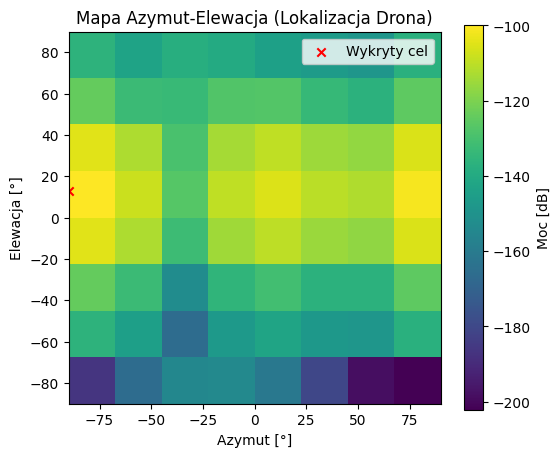

In [13]:
h_spatial_1d = h[:, idx_doppler, idx_range]

h_spatial_2d = h_spatial_1d.reshape((8, 8))

window_2d = np.outer(np.hanning(8), np.hanning(8))
h_spatial_windowed = h_spatial_2d * window_2d

angle_map_2d = np.fft.fftshift(np.fft.fft2(h_spatial_windowed))
angle_power_db = 20 * np.log10(np.abs(angle_map_2d) + 1e-12)

idx_el, idx_az = np.unravel_index(np.argmax(angle_power_db), (8, 8))

katy_lin = np.linspace(-90, 90, 8)
wykryty_azymut = katy_lin[idx_az]
wykryta_elewacja = katy_lin[idx_el]

print(f"\n--- POZYCJA 3D (NAMIERZANIE) ---")
print(f"Azymut (Lewo/Prawo): {wykryty_azymut:.2f}°")
print(f"Elewacja (Góra/Dół): {wykryta_elewacja:.2f}°")

plt.figure(figsize=(6, 5))
plt.imshow(angle_power_db, extent=[-90, 90, -90, 90], origin='lower')
plt.colorbar(label='Moc [dB]')
plt.title('Mapa Azymut-Elewacja (Lokalizacja Drona)')
plt.xlabel('Azymut [°]')
plt.ylabel('Elewacja [°]')
plt.scatter(wykryty_azymut, wykryta_elewacja, color='red', marker='x', label='Wykryty cel')
plt.legend()
plt.show()